# Regresi Linear

In [1]:
# Libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [2]:
# Data Preparation
df = pd.read_excel("Final_PM15.xlsx")

# Cleaning
df['MDWT'] = pd.to_numeric(df['MDWT'], errors='coerce')
df = df.dropna()

# Cleaning - GSM
df['GSM'] = df['GSM'].astype(str)
df = df[df['GSM'].str.len() <= 4].copy()
df['GSM'] = df['GSM'].str.replace(',', '.')
df['GSM'] = df['GSM'].astype(float)

# Create Pseudo_Mass Feature
df['pseudo_mass'] = (df['Mean_Stock Flow'] * df['Mean_Stock Consistency'])/ df['Mean_Yankee Speed']

# Create Coating-Release Ratio Feature
df['coating_release_ratio'] = df['Mean_Flow Coating'] / df['Mean_Flow Release']

# X Variables
features = [
    'Mean_Creping'
]
X = df[features]


# Y Variables
target = 'MDS'
y = df[target]


In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 185 entries, 0 to 371
Data columns (total 40 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Start_Time              185 non-null    datetime64[us]
 1   End_Time                185 non-null    datetime64[us]
 2   Data_Count              185 non-null    int64         
 3   Mean_Creping            185 non-null    float64       
 4   Mean_Yankee Speed       185 non-null    float64       
 5   Mean_Pope Reel Speed    185 non-null    float64       
 6   Mean_Yankee Pressure    185 non-null    float64       
 7   Mean_Stock Flow         185 non-null    float64       
 8   Mean_Stock Consistency  185 non-null    float64       
 9   Mean_Flow Coating       185 non-null    float64       
 10  Mean_Flow Release       185 non-null    float64       
 11  Mean_Jet Wire Ratio     185 non-null    float64       
 12  Mean_Load KWH Refiner   185 non-null    float64       
 13  Join_K

In [27]:
# Model Regresi Linear
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                    MDS   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                          7.785e+04
Date:                Tue, 05 May 2026   Prob (F-statistic):                   1.10e-243
Time:                        13:53:13   Log-Likelihood:                         -321.29
No. Observations:                 185   AIC:                                      644.6
Df Residuals:                     184   BIC:                                      647.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

In [5]:
# --- OPSI 1: Model Tanpa Intercept (Sesuai kode awal Anda) ---
model_no_const = sm.OLS(y, X).fit()
y_pred_no = model_no_const.predict(X)

mape_no = np.mean(np.abs((y - y_pred_no) / y)) * 100
r2_no = model_no_const.rsquared  # Mengambil R-sq uncentered

print("--- Model Tanpa Intercept ---")
print(f"R-squared: {r2_no:.4f}")
print(f"MAPE: {mape_no:.2f}%")

# --- OPSI 2: Model Dengan Intercept (Disarankan untuk validasi) ---
X_with_const = sm.add_constant(X)
model_with_const = sm.OLS(y, X_with_const).fit()
y_pred_with = model_with_const.predict(X_with_const)

mape_with = np.mean(np.abs((y - y_pred_with) / y)) * 100
r2_with = model_with_const.rsquared # Mengambil R-sq standar

print("\n--- Model Dengan Intercept ---")
print(f"R-squared: {r2_with:.4f}")
print(f"MAPE: {mape_with:.2f}%")

--- Model Tanpa Intercept ---
R-squared: 0.9976
MAPE: 3.84%

--- Model Dengan Intercept ---
R-squared: 0.8626
MAPE: 3.75%


In [7]:
print(model_with_const.summary())

                            OLS Regression Results                            
Dep. Variable:                    MDS   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     1149.
Date:                Tue, 05 May 2026   Prob (F-statistic):           8.41e-81
Time:                        14:55:07   Log-Likelihood:                -320.75
No. Observations:                 185   AIC:                             645.5
Df Residuals:                     183   BIC:                             651.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.8912      0.860     -1.036   

In [6]:
print(model_no_const.summary())

                                 OLS Regression Results                                
Dep. Variable:                    MDS   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                          7.785e+04
Date:                Tue, 05 May 2026   Prob (F-statistic):                   1.10e-243
Time:                        14:54:58   Log-Likelihood:                         -321.29
No. Observations:                 185   AIC:                                      644.6
Df Residuals:                     184   BIC:                                      647.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

## Pemeriksaan Asumsi IIDN

### Independen (Autokorelasi)

In [28]:
DW = sm.stats.durbin_watson(model.resid)
print('Nilai DW =', DW)
if DW > 1.5 and DW < 2.5:
    print('Tidak ada autokorelasi (baik positif maupun negatif)')
elif DW < 1.5:
    print('Terdapat autokorelasi positif.')
elif DW > 2.5:
    print('Terdapat autokorelasi negatif.')

Nilai DW = 1.8391408907739355
Tidak ada autokorelasi (baik positif maupun negatif)


### Indentik (Heterokesdastisitas)

In [29]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Breusch-Pagan Test
# H0: Homoskedastisitas (Varians konstan)
bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

ValueError: The Breusch-Pagan test requires exog to have at least two columns where one is a constant.

Terjadi Heteroskedastisitas yang parah pada model. Varians dari residual terbukti secara empiris tidak konstan.

### Normalitas

In [ ]:
# Libraries
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

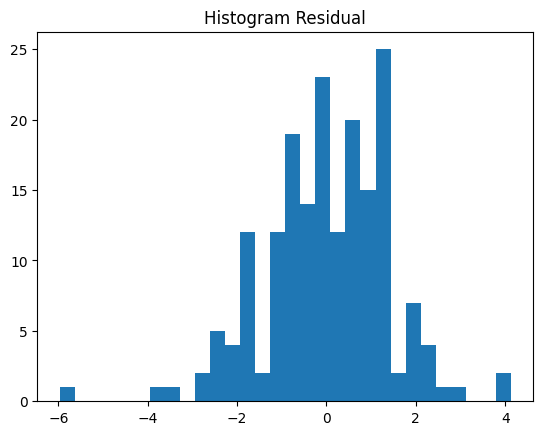

In [ ]:
# Histogram
plt.figure()
plt.hist(model.resid, bins=30)
plt.title("Histogram Residual")
plt.show()

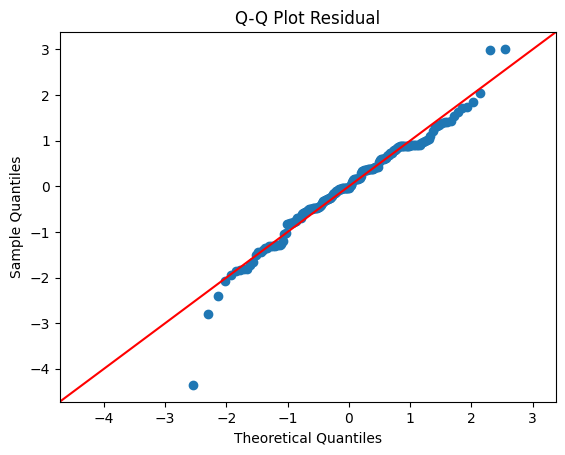

In [ ]:
# Visualisasi (Q-Q Plot)
sm.qqplot(model.resid, line='45', fit=True)
plt.title("Q-Q Plot Residual")
plt.show()

In [ ]:
# Uji Statistik (Shapiro-Wilk)
# H0: Data berdistribusi normal
# H1: Data tidak berdistribusi normal

stat, p_value = stats.shapiro(model.resid)

# Jika p-value < 0.05, residual tidak berdistribusi normal
print(f"Shapiro-Wilk Test: p-value = {p_value}")
if p_value < 0.05:
    print('residual tidak berdistribusi normal')
else:
    print('residual berdistribusi normal.')

Shapiro-Wilk Test: p-value = 0.0019684539727251957
residual tidak berdistribusi normal


### Multikolinearitas

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF untuk setiap variabel independen
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

        Feature        VIF
0         const  72.093009
1  Mean_Creping   1.000000
